# Telecom X - Parte 2: Predicción de Cancelación (Churn)

In [ ]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# 1. Carga de datos y Análisis exploratorio

## 1. Carga de datos

In [ ]:
# base de datos cargada en la nube de github
url='https://raw.githubusercontent.com/WLozanoH/TelecomX-Churn-Prediction-ML/main/Data_churn_ML'

datos = pd.read_csv(url)

## 2. Exploración inicial

In [ ]:
datos.head()

,customerid,abandono,genero,clientes_senior_(>=65_años),tiene_pareja,tiene_dependientes,meses_de_contrato,servicio_telefonico,multiples_lineas_telefonicas,proveedor_de_internet,...,proteccion_de_dispositivo,soporte_tecnico,streaming_de_tv,streaming_de_peliculas,tipo_contrato,factura_electronica,forma_de_pago,cargo_mensual,cargo_total,cuentas_diarias
0,0002-orfbo,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.796667


## 2.1 Eliminar columnas irrelevantes
  * customerid, genero: no aporta valor al análisis o a los modelos predictivos

In [ ]:
# eliminar variables irrelevantes
datos = datos.drop(columns=['customerid', 'genero'])

* Análisis de la variable objetivo
  * Gráfico de histograma con px

In [ ]:
datos['abandono'].value_counts()

,count
abandono,
0,5398
1,1869


In [ ]:
datos['abandono'] = datos['abandono'].apply(lambda x: 'si' if x==1 else 'no')

In [ ]:
px.histogram(datos, x='abandono', text_auto=True)

### 2.2. Análisis de variables categóricas
  * Graficar histogramas para cada variable categóricas diferenciándolo por la variable objetivo 'abandono' usando la librería plotly.
  * Columnas con más de dos clases.

In [ ]:
# variables categóricas
var_categoricas = [col for col in datos.columns if datos[col].nunique()>2 and datos[col].dtype=='object']
var_categoricas

['proveedor_de_internet', 'tipo_contrato', 'forma_de_pago']

In [ ]:
# proveedor_de_internet
px.histogram(datos, x='proveedor_de_internet', color='abandono', text_auto=True)

In [ ]:
# tipo de contrato
px.histogram(datos, x='tipo_contrato', color='abandono', text_auto=True)

In [ ]:
# forma de pago
px.histogram(datos, x='forma_de_pago', color='abandono', text_auto=True)

### 2.3. Análisis de variables categóricas(binarias)
  * Graficar histogramas para cada variable categóricas diferenciándolo por la variable objetivo 'abandono' usando la librería seaborn.
  * Columnas con sólo dos clases.

In [ ]:
# columnas binarias y diferente de abandono y genero
var_binarias = [col for col in datos.columns if col != 'abandono' and datos[col].nunique() == 2 and col != 'genero']
var_binarias

['clientes_senior_(>=65_años)',
 'tiene_pareja',
 'tiene_dependientes',
 'servicio_telefonico',
 'multiples_lineas_telefonicas',
 'seguridad_en_linea',
 'respaldo_en_linea',
 'proteccion_de_dispositivo',
 'soporte_tecnico',
 'streaming_de_tv',
 'streaming_de_peliculas',
 'factura_electronica']

In [ ]:
# Adicionamos los colores al proyecto
ROJO_1,	ROJO_2,	ROJO_3 = "#e23155",	"#cc2c4e", "#b32742"
AZUL_1,	AZUL_2,	AZUL_3 = "#203f75",	"#1c3867", "#19325b"
BLANCO,GRIS_1, GRIS_2, GRIS_3, GRIS_4,	GRIS_5 = "#ffffff", "#ebebeb",	"#d9d9d9", "#cccccc", "#555655", "#231f20"
AQUA_1,	AQUA_2,	AQUA_3 = "#addcd4",	"#9fccc5", "#96bfb9"

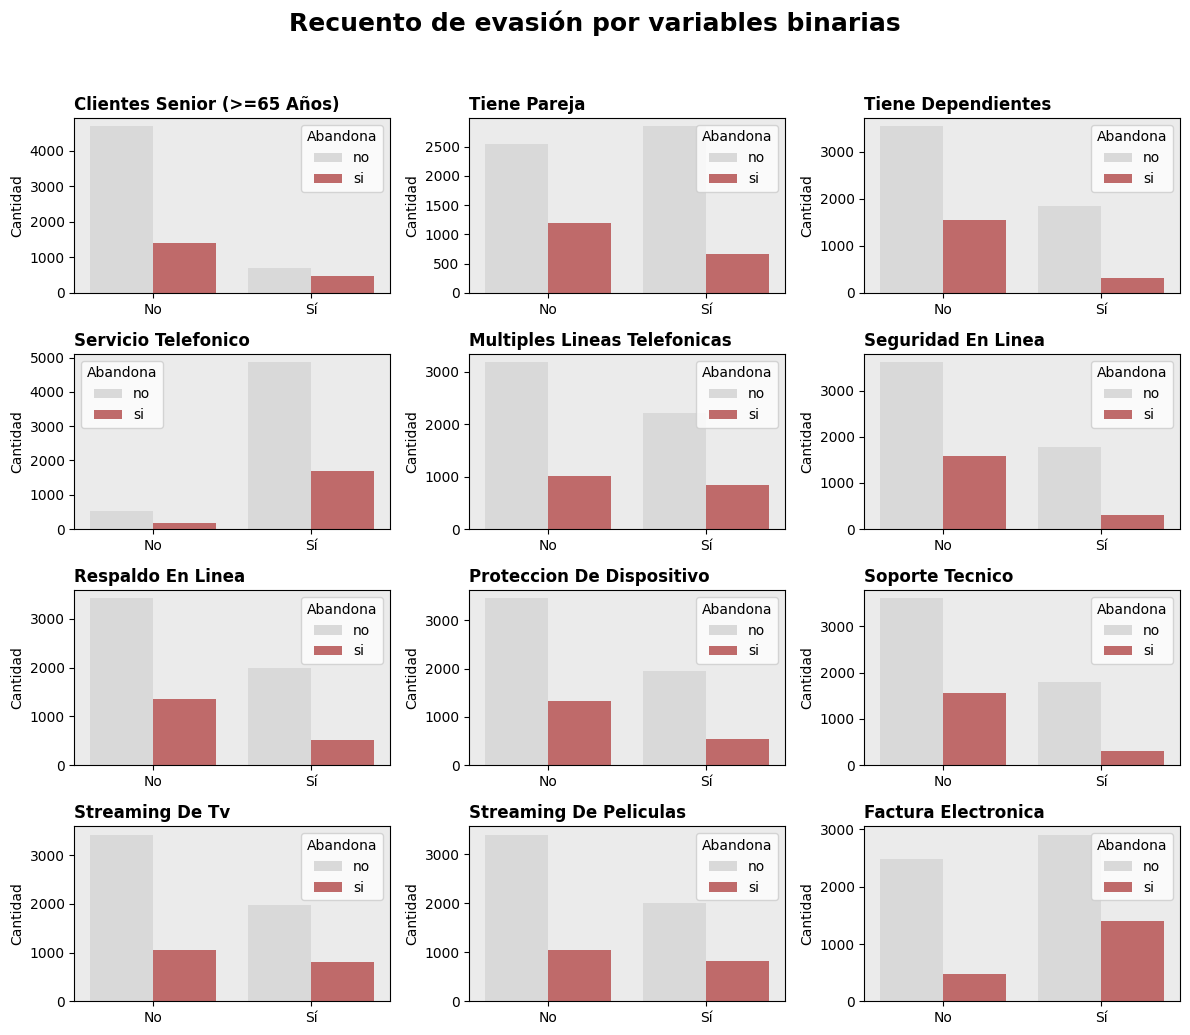

In [ ]:
# Iterar y graficar todas las variables binarias en un grafico de boxplot
# Crear figura con 3 filas y 4 columnas
fig, axes = plt.subplots(4,3,figsize=(12,10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Recuento de evasión por variables binarias', fontsize=18, fontweight='bold', y=1.03)
axes = axes.flatten() # Aplanar array de ejes

# Recorrer las variables y graficar:
for i, var in enumerate(var_binarias):
  ax = axes[i]
  sns.countplot(data=datos, x=var, hue='abandono', ax=ax, palette={'no': GRIS_2, 'si': 'indianred'})

  # Convertir var a formato legible: reemplazar "_" y poner formato título
  titulo = var.replace("_", " ").title()
  ax.set_title(titulo, fontsize=12, loc='left', fontweight='bold')

  ax.set_ylabel('Cantidad')
  ax.set_xlabel('') # Quitar etiquetas del eje X
  ax.set_xticklabels(['No', 'Sí']) #Porque son variables binarias

# Estilo de fondo
  ax.set_facecolor(GRIS_1)
  ax.patch.set_color(GRIS_1)

# Cambiar etiquetas de la leyenda
  handles, labels = ax.get_legend_handles_labels()
  ax.legend(handles=handles, labels=['no', 'si'], title='Abandona')

# Ocultar subplots vacíos si hay más o menos variables binarias
for j in range(len(var_binarias), len(axes)):
    fig.delaxes(axes[j])

#Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()

### 2.4. Análisis de variables numéricas
  * Graficar boxplot para cada variable numérica diferenciándolo por la variable objetivo 'abandono' usando la librería plotly.

In [ ]:
var_numericas = [col for col in datos.select_dtypes(include='number').columns if col != 'abandono' and datos[col].nunique() !=2]
var_numericas

['meses_de_contrato', 'cargo_mensual', 'cargo_total', 'cuentas_diarias']

In [ ]:
# meses de contrato
px.box(datos, x='meses_de_contrato', color='abandono')

In [ ]:
# cuentas_diarias
px.box(datos, x='cuentas_diarias', color='abandono')

In [ ]:
# cargo mensual
px.box(datos, x='cargo_mensual', color='abandono')

In [ ]:
# cargo total
px.box(datos, x='cargo_total', color='abandono')

* Usaré los datos de clientes que pagan solo hasta 8600

In [ ]:
print(f'Filas antes: {datos.shape[0]}')
# pocos outliers mayores a 8600, los eliminamos
datos = datos[datos['cargo_total'] < 8600]
print(f'Filas después: {datos.shape[0]}')

Filas antes: 7267
Filas después: 7264


# 2. Separación entre variables y objetivo

Antes de predecir un modelo con machine learning, es importante separar los datos en dos partes:
* y: **la variable objetivo**, es decir, lo que queremos predecir(por ejemplo: si un cliente abandona o no)
* X: **las variables explicativas**, que son los datos o características que usaremos para hacer la predicción (como genero, tipo de contrato, cargo total, etc)

In [ ]:
from sklearn.model_selection import train_test_split

# Separando los datos en X e y
X = datos.drop(columns='abandono')  # tu variable objetivo
y = datos['abandono']

# 3. Separación de datos en entrenamiento y prueba

In [ ]:
# Convertir y a valores numéricos (1/0) con LabelEncoder
from sklearn.preprocessing import LabelEncoder

# instanciar LabelEncoder
LabelEncoder = LabelEncoder()

# Ajustar y transformar la variable objetivo
y_encoded = LabelEncoder.fit_transform(y)

# Dividir datos: 80% entrenamiento, 20% prueba
X, X_test, y, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Preprocesamiento

## 4.1. Transformando las variables explicativas

Los algoritmos de machine learning no entienden texto, solo números. Por eso, necesitamos convertir los datos de texto en números. Pero esta conversión debe hacerse con cuidado, sin cambiar el significado original de los datos. No se trata solo de poner cualquier número al azar.

### Encoding:
  * Codificación de las variables categóricas a formato numérico para hacerlas compatibles con modelos de machine learning.
    * Usar: **OneHotEncoder**
      * OneHotEncoder: transforma los valores de las columnas en 0 y 1 en un array
      * Dado que se integra con **pipelines** y lo usaremos para el flujo de trabajo

    * Usar: **Column_transformer**
      * Es una clase más flexible y explícita que **make_column_transformer**.
      * Permite nombrar los pasos manualmente.
      * Es más clara para pipelines grandes o cuando quieres control más detallado.

In [ ]:
# importar librerías
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Detectar columnas
num_cols = [col for col in X.select_dtypes(include='number').columns if X[col].nunique() !=2] # columnas numéricas
cat_cols = [col for col in X.select_dtypes(include='object').columns if X[col].nunique() >2] # columnas categóricas
bin_cols = [col for col in X.select_dtypes(include='number').columns if X[col].nunique()==2] # columnas binarias

# Preprocesador
preprocesador = ColumnTransformer(transformers=[

    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', bin_cols)

])


## 4.1. Transformando la variable respuesta (objetivo)

Al igual que las variables explicativas, la variable objetivo también debe estar en formato numérico. Si es binaria (dos categorías), podemos representarla con 0 y 1:

0 = no tiene la característica
1 = sí la tiene
LabelEncoder: Uso principal, codificar la variable objetivo(y)

para clasificación multiclase o binaria
Ya la transformamos al inicio, antes de separar los datos en entrenamiento y prueba

## 5. Modelo de referencia - Baseline

* Es el modelo más simple que se puede usar. Consiste en predecir siempre la clase que más se repite en los datos (por ejemplo, siempre decir que un cliente no abandona si esa es la mayoría).
* Por defecto predice el valor previo.(prior)

* Este modelo no usa ningún algoritmo complejo, pero sirve como punto de comparación: si un modelo más avanzado no mejora este resultado, entonces no está haciendo bien su trabajo.

* Siempre se usa un clasificador dummy.

✅ Esto nos da una métrica mínima que cualquier modelo debe superar.

In [ ]:
# importar la libreria
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# instanciar el modelo dummy
dummy = DummyClassifier() # por defecto 'strategy' = 'prior'

# entrenar el modelo con dummy
dummy.fit(X, y) # entrena con los datos de entrenamiento

# probar en los datos de prueba
score_dummy = dummy.score(X_test, y_test) # evalúa con accuracy: exactitud
print(f'Accuracy del modelo dummy: {score_dummy:.4f}')

y_predict_dummy = dummy.predict(X_test) # predicciones

# metricas para dummy
print(f'\nResumen de métricas para modelo base -dummy:\n\n {classification_report(y_test, y_predict_dummy)}')

Accuracy del modelo dummy: 0.7385

Resumen de métricas para modelo base -dummy:

               precision    recall  f1-score   support

           0       0.74      1.00      0.85      1073
           1       0.00      0.00      0.00       380

    accuracy                           0.74      1453
   macro avg       0.37      0.50      0.42      1453
weighted avg       0.55      0.74      0.63      1453



# 6. Análisis de correlación

## 6.1. Datos preprocesados para la correlación

In [95]:
# Obtener datos preprocesados
X_procesado = preprocesador.fit_transform(X)

# Unir con la variable objetivo

X_procesado_df = pd.DataFrame(X_procesado.toarray() if hasattr(X_procesado, 'toarray') else X_procesado, columns = preprocesador.get_feature_names_out())
#X_procesados = pd.DataFrame(X_procesados, columns=preprocesador.get_feature_names_out())
X_procesado_df['abandono'] = y
X_procesado_df.head()

,num__meses_de_contrato,num__cargo_mensual,num__cargo_total,num__cuentas_diarias,cat__proveedor_de_internet_dsl,cat__proveedor_de_internet_fiber optic,cat__proveedor_de_internet_no,cat__tipo_contrato_month-to-month,cat__tipo_contrato_one year,cat__tipo_contrato_two year,...,bin__servicio_telefonico,bin__multiples_lineas_telefonicas,bin__seguridad_en_linea,bin__respaldo_en_linea,bin__proteccion_de_dispositivo,bin__soporte_tecnico,bin__streaming_de_tv,bin__streaming_de_peliculas,bin__factura_electronica,abandono
0,0.354006,-0.302115,-0.019222,-0.302115,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,-0.744235,0.677965,-0.504773,0.677965,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
2,0.028601,-1.470225,-0.703242,-1.470225,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.126842,-0.500128,0.348538,-0.500128,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0
4,-0.256128,-1.481872,-0.790020,-1.481872,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


## 6.2. 📈 Calcular la matriz de correlación

In [96]:
# Matriz de correlación
correlacion_matrix = X_procesado_df.corr()

## 6.3. 🎨 Visualizar la matriz con una máscara triangular

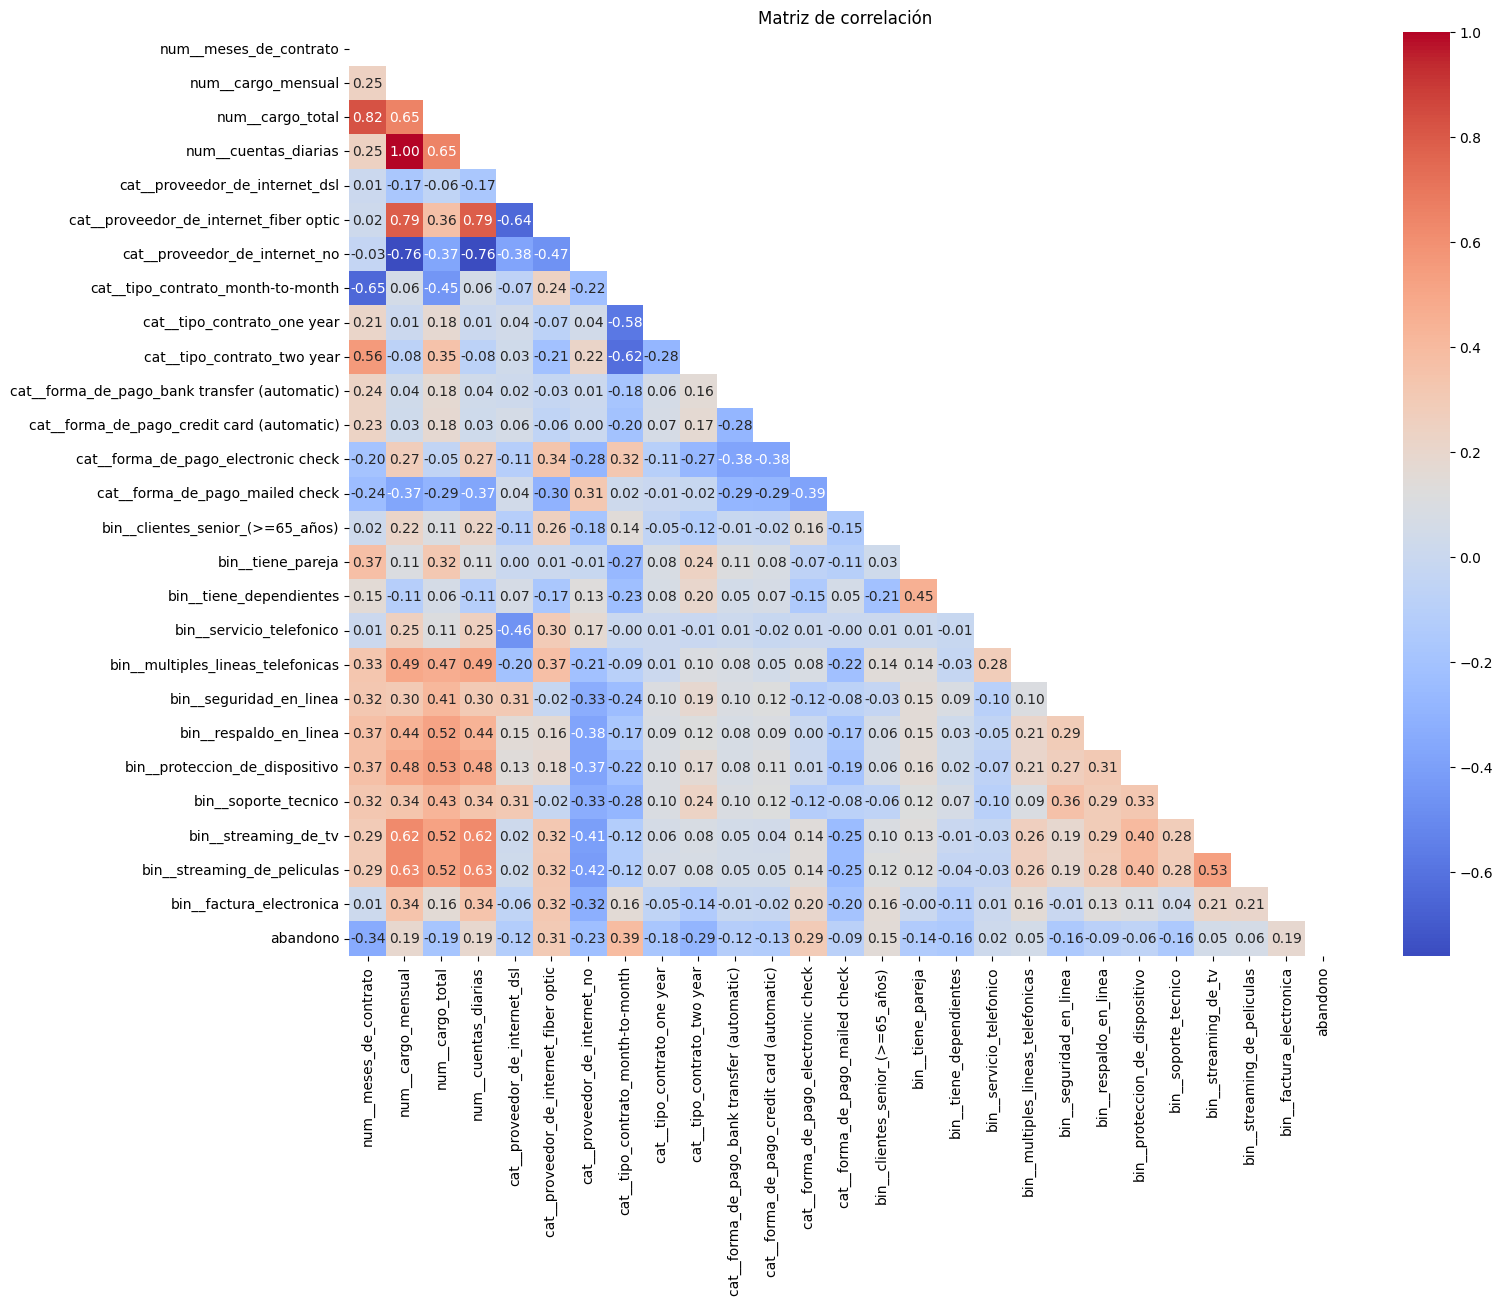

In [97]:
# Crear máscara para ocultar la mitad superior
mascara = np.triu(np.ones_like(correlacion_matrix, dtype='bool'))

# Gráfico de calor
plt.figure(figsize=(16,12))
sns.heatmap(correlacion_matrix, mask=mascara, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

In [98]:
# Correlación con la variable 'abandono'
correlaciones = correlacion_matrix['abandono'].sort_values(ascending=False)
print(correlaciones)

abandono                                        1.000000
cat__tipo_contrato_month-to-month               0.390383
cat__proveedor_de_internet_fiber optic          0.305501
cat__forma_de_pago_electronic check             0.292310
num__cargo_mensual                              0.192684
num__cuentas_diarias                            0.192684
bin__factura_electronica                        0.185705
bin__clientes_senior_(>=65_años)                0.148081
bin__streaming_de_peliculas                     0.063067
bin__multiples_lineas_telefonicas               0.048122
bin__streaming_de_tv                            0.046370
bin__servicio_telefonico                        0.021087
bin__proteccion_de_dispositivo                 -0.063449
cat__forma_de_pago_mailed check                -0.088752
bin__respaldo_en_linea                         -0.089784
cat__forma_de_pago_bank transfer (automatic)   -0.116810
cat__proveedor_de_internet_dsl                 -0.124870
cat__forma_de_pago_credit card 

# 7. Análisis Dirigido

Investigar variables específicas se relacionan con la cancelación, tales como:

* Tiempo de contrato × Cancelación
* Gasto total × Cancelación

Utilizar gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

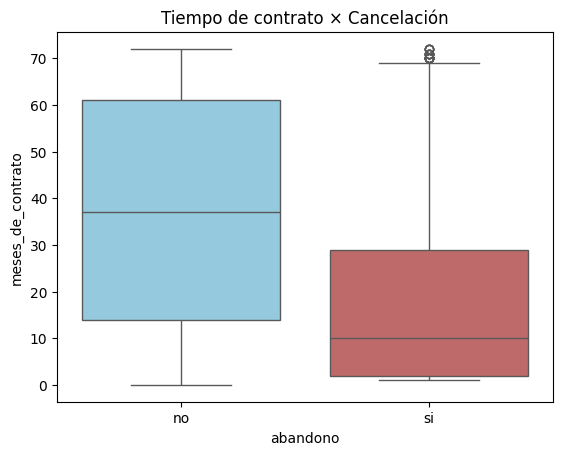

In [114]:
# Gráfico de Tiempo de contrato × Cancelación
sns.boxplot(data=datos,
            x='abandono', y='meses_de_contrato', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Tiempo de contrato × Cancelación')
plt.show()

In [100]:
# agrupar por abandono == 1 y obtener las metricas estadísticas de meses de contrato
datos.groupby('abandono')['meses_de_contrato'].describe()

,count,mean,std,min,25%,50%,75%,max
abandono,,,,,,,,
no,5396.0,37.308191,24.173625,0.0,14.0,37.0,61.0,72.0
si,1868.0,17.950214,19.496286,1.0,2.0,10.0,29.0,72.0


* Los clientes que tienen en contratos cortos, son los que tienen mayor tasa de abandono.

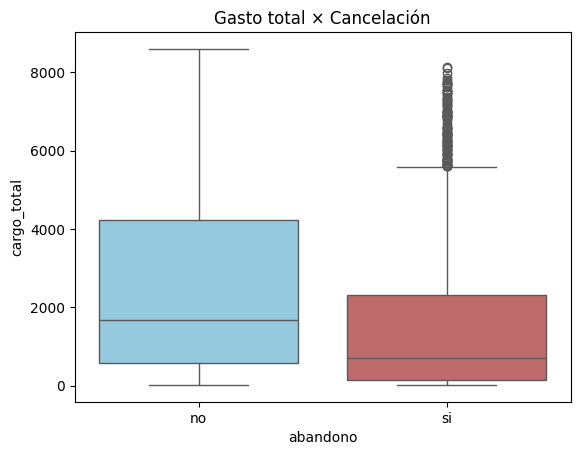

In [113]:
# Gráfico de Gasto total × Cancelación
sns.boxplot(data=datos,
            x='abandono', y='cargo_total', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Gasto total × Cancelación')
plt.show()

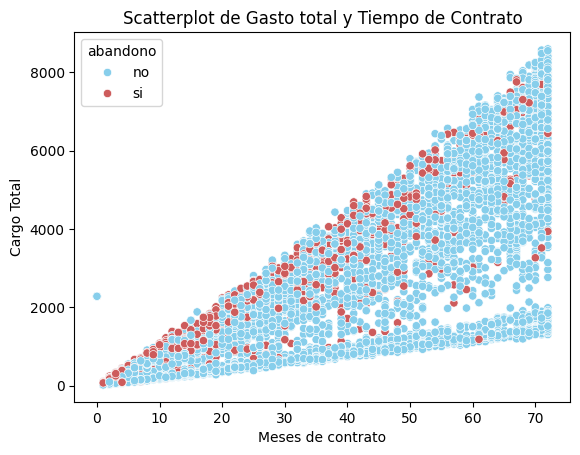

In [112]:
# Gráfico de Scatterplot de gasto total y tiempo de contrato
sns.scatterplot(data=datos, x='meses_de_contrato', y='cargo_total', hue='abandono', palette={'no':'skyblue', 'si':'indianred'})
plt.title('Scatterplot de Gasto total y Tiempo de Contrato')
plt.xlabel('Meses de contrato')
plt.ylabel('Cargo Total')
plt.show()

In [103]:
# correlación entre gasto total y tiempo de contrato
datos[['cargo_total', 'meses_de_contrato']].corr()

,cargo_total,meses_de_contrato
cargo_total,1.000000,0.823951
meses_de_contrato,0.823951,1.000000


* En el gráfico de dispersión, se observa que:
  * Existe una relación positiva fuerte entre meses de contrato y cargo total, es decir a medida que aumenta los meses de contrato, también aumenta el cargo total.
  * Además, se observa que clientes con contratos cortos proporcional su cargo total (cargo total bajo), están abandonando la empresa.
* En el gráfico de boxplot, se evidencia con claridad que:
  * La mayor cantidad de clientes que tienen un cargo total alto no están abandonando la empresa.